# finportfolio — Tutorial en Español

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mikehv03/finportfolio/blob/main/notebooks/tutorial_es.ipynb)

**finportfolio** es una librería de Python para teoría de portafolios y valuación de activos. Implementa:

- Optimización media-varianza de Markowitz
- CAPM, APT y el Modelo de Gordon
- Modelo de Índice Simple y modelos de factores Fama-French
- Métricas de desempeño y riesgo de portafolios
- Descarga de datos de mercado vía yfinance

---

## 1. Instalación

In [1]:
!pip install finportfolio

## 2. Carga de Datos de Mercado

Descargamos los precios de cierre ajustados para un portafolio de 6 activos y el S&P 500, que utilizaremos como benchmark.

In [2]:
from finportfolio.data import get_prices, get_ff_factors

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "NVDA"]
BENCHMARK = ["SPY"]
START = "2010-01-01"
END = "2024-12-31"

prices = get_prices(TICKERS, start_date=START, end_date=END)
benchmark_prices = get_prices(BENCHMARK, start_date=START, end_date=END)

print(f"Dimensiones del portafolio: {prices.shape}")
prices.head()

Dimensiones del portafolio: (3773, 6)


,AAPL,MSFT,GOOGL,AMZN,JPM,NVDA
Date,,,,,,
2010-01-04,6.412382,23.077379,15.555863,6.6950,28.279213,0.423784
2010-01-05,6.423469,23.084841,15.487362,6.7345,28.826973,0.429972
2010-01-06,6.321294,22.943163,15.096946,6.6125,28.985369,0.432722
2010-01-07,6.309610,22.704565,14.745495,6.5000,29.559515,0.424242
2010-01-08,6.351557,22.861149,14.942071,6.6760,29.486929,0.425159


También descargamos los factores de Fama-French para su uso posterior en la sección de modelos de factores.

In [3]:
# Descargar factores Fama-French
ff_factors = get_ff_factors(start_date=START, end_date=END)
print(f"Dimensiones de factores FF: {ff_factors.shape}")
ff_factors.head()

Dimensiones de factores FF: (3774, 4)


,Mkt-RF,SMB,HML,RF
Date,,,,
2010-01-04,0.0169,0.0061,0.0114,0.0
2010-01-05,0.0031,-0.0064,0.0122,0.0
2010-01-06,0.0013,-0.0023,0.0055,0.0
2010-01-07,0.0040,0.0009,0.0096,0.0
2010-01-08,0.0033,0.0036,0.0002,0.0


## 3. Cálculo de Rendimientos

Calculamos los rendimientos simples diarios a partir de los precios de cierre ajustados.

In [4]:
from finportfolio.returns import compute_returns, summary_stats, annualize_returns

returns = compute_returns(prices, method="simple")
benchmark_returns = compute_returns(benchmark_prices, method="simple")

stats = summary_stats(returns, rf=0.0)
print("Estadísticas descriptivas (frecuencia diaria):")
stats

Estadísticas descriptivas (frecuencia diaria):


,mean,std,skewness,excess_kurtosis,min,max,sharpe_ratio
AAPL,0.001127,0.017554,-0.043242,5.199753,-0.128647,0.119808,0.064181
MSFT,0.000900,0.016111,0.026411,7.654074,-0.147390,0.142169,0.055846
GOOGL,0.000812,0.017218,0.363802,8.201316,-0.116342,0.162584,0.047151
AMZN,0.001140,0.020616,0.260114,6.243431,-0.140494,0.157457,0.055282
JPM,0.000711,0.017494,0.230536,9.926435,-0.149649,0.180125,0.040642
NVDA,0.001940,0.028624,0.620241,8.147236,-0.187559,0.298067,0.067760


Anualizamos los rendimientos esperados escalando la media muestral por el número de días de trading en el año (252).

In [5]:
ann_returns = annualize_returns(returns, periods_per_year=252, method="simple")
print("Rendimientos Esperados Anualizados:")
print(ann_returns.apply(lambda x: f"{x:.2%}"))

Rendimientos Esperados Anualizados:
AAPL     32.81%
MSFT     25.44%
GOOGL    22.69%
AMZN     33.25%
JPM      19.61%
NVDA     62.95%
dtype: str


## 4. Optimización de Markowitz

Encontramos el portafolio de mínima varianza global utilizando datos anualizados.

In [6]:
from finportfolio.optimization import Markowitz

# Datos anualizados
m = Markowitz(returns, annualize=True, periods_per_year=252)

# Portafolio de mínima varianza global
gmv_weights = m.min_variance()
print("Ponderadores del Portafolio de Mínima Varianza Global:")
print(gmv_weights.apply(lambda x: f"{x:.2%}"))

Ponderadores del Portafolio de Mínima Varianza Global:
AAPL     22.03%
MSFT     28.96%
GOOGL    18.81%
AMZN      7.60%
JPM      32.00%
NVDA     -9.40%
dtype: str


**Nota:** Los ponderadores negativos indican posiciones cortas, las cuales están permitidas en el marco no restringido de Markowitz.

In [7]:
# Desempeño del portafolio de mínima varianza global
gmv_perf = m.portfolio_performance(gmv_weights, rf=0.05)
print("Desempeño del Portafolio GMV:")
print(f"  Rendimiento Esperado: {gmv_perf['expected_return']:.2%}")
print(f"  Riesgo (std):         {gmv_perf['risk']:.2%}")
print(f"  Razón de Sharpe:      {gmv_perf['sharpe_ratio']:.4f}")

Desempeño del Portafolio GMV:
  Rendimiento Esperado: 19.99%
  Riesgo (std):         21.03%
  Razón de Sharpe:      0.7127


In [8]:
# Portafolio óptimo para un rendimiento objetivo
target_return = 0.30  # rendimiento anual objetivo del 30%
optimal_weights = m.optimal_portfolio(return_target=target_return)
optimal_perf = m.portfolio_performance(optimal_weights, rf=0.05)

print(f"Portafolio Óptimo (rendimiento objetivo = {target_return:.0%}):")
print(optimal_weights.apply(lambda x: f"{x:.2%}"))
print(f"\n  Rendimiento Esperado: {optimal_perf['expected_return']:.2%}")
print(f"  Riesgo (std):         {optimal_perf['risk']:.2%}")
print(f"  Razón de Sharpe:      {optimal_perf['sharpe_ratio']:.4f}")

Portafolio Óptimo (rendimiento objetivo = 30%):
AAPL     36.48%
MSFT     11.77%
GOOGL    -2.94%
AMZN     18.16%
JPM      17.74%
NVDA     18.78%
dtype: str

  Rendimiento Esperado: 30.00%
  Riesgo (std):         24.34%
  Razón de Sharpe:      1.0273


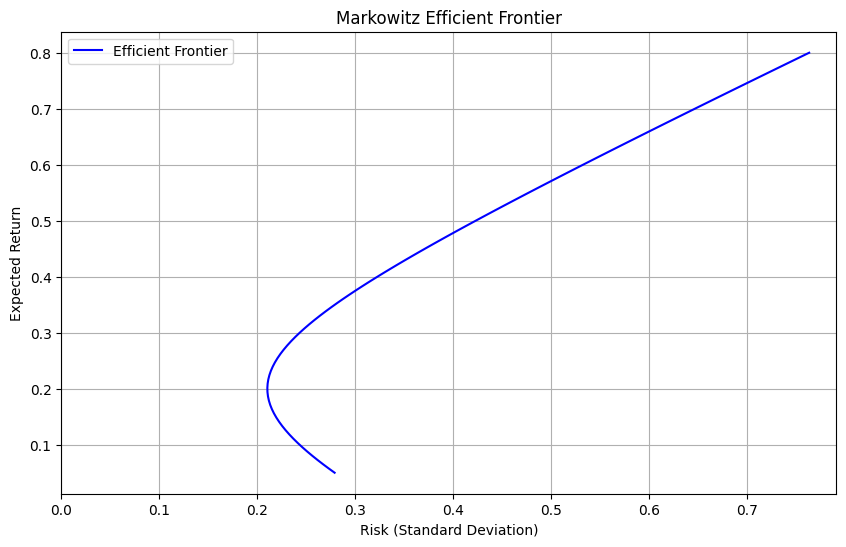

In [9]:
# Graficar la frontera eficiente
m.plot_frontier(minimum_return=0.05, maximum_return=0.80)

## 5. Tobin — Línea de Asignación de Capital

Agregamos un activo libre de riesgo (rf = 5% anual) y encontramos el portafolio de tangencia.

In [10]:
from finportfolio.optimization import Tobin

risk_free_rate = 0.05

t = Tobin(returns, rf=risk_free_rate, annualize=True, periods_per_year=252)

# Portafolio de tangencia
tang_weights = t.tangency_portfolio()
print("Ponderadores del Portafolio de Tangencia:")
print(tang_weights.apply(lambda x: f"{x:.2%}"))

Ponderadores del Portafolio de Tangencia:
AAPL      50.51%
MSFT      -4.92%
GOOGL    -24.07%
AMZN      28.42%
JPM        3.89%
NVDA      46.17%
dtype: str


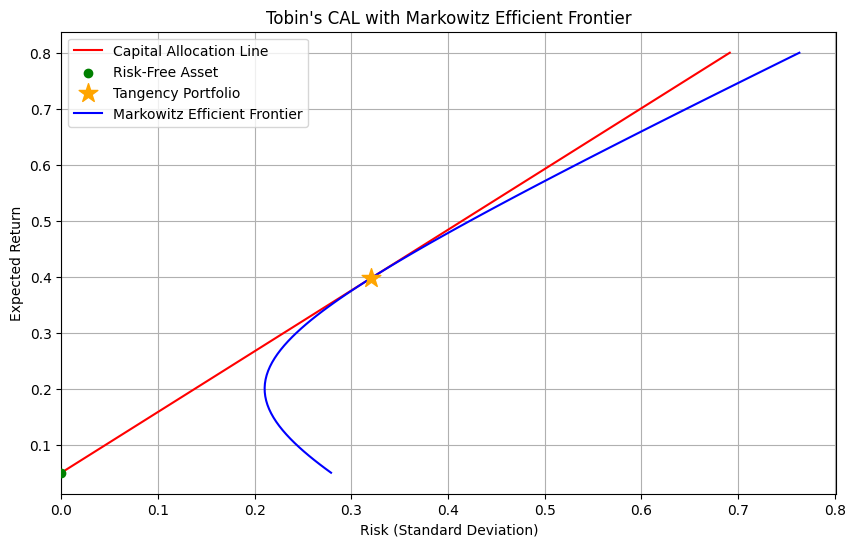

In [11]:
# Graficar la CAL junto con la frontera de Markowitz
t.plot_frontier(minimum_return=0.05, maximum_return=0.80, include_markowitz=True)

## 6. CAPM y Modelos de Equilibrio

Utilizamos el CAPM para estimar el riesgo sistemático (beta) de cada activo y calcular los rendimientos esperados de equilibrio en función de su exposición al mercado.

In [12]:
from finportfolio.equilibrium import estimate_beta, capm_expected_return, security_market_line, plot_security_market_line
import pandas as pd

spy_returns = benchmark_returns["SPY"]
rf_daily = risk_free_rate / 252

# Estimar beta para cada activo
betas = {}
for ticker in TICKERS:
    beta = estimate_beta(
        returns[ticker] - rf_daily,
        spy_returns - rf_daily
    )
    betas[ticker] = beta

betas_series = pd.Series(betas)
print("Betas estimadas vs SPY:")
print(betas_series.apply(lambda x: f"{x:.4f}"))

Betas estimadas vs SPY:
AAPL     1.1180
MSFT     1.1318
GOOGL    1.1028
AMZN     1.1493
JPM      1.1991
NVDA     1.6571
dtype: str


Usando las betas estimadas y el rendimiento anualizado del SPY como rendimiento de mercado, calculamos el rendimiento esperado de equilibrio bajo el CAPM para cada activo.

In [13]:
# Rendimientos esperados bajo el CAPM
market_return = annualize_returns(benchmark_returns, periods_per_year=252)["SPY"]

capm_returns = {}
for ticker in TICKERS:
    capm_returns[ticker] = capm_expected_return(risk_free_rate, betas[ticker], market_return)

print("Rendimientos Esperados CAPM (anuales):")
for ticker, r in capm_returns.items():
    print(f"  {ticker}: {r:.2%}")

Rendimientos Esperados CAPM (anuales):
  AAPL: 16.60%
  MSFT: 16.74%
  GOOGL: 16.44%
  AMZN: 16.92%
  JPM: 17.44%
  NVDA: 22.19%


Construimos la Línea del Mercado de Valores (SML) con todos los datos disponibles.

In [14]:
# Línea del Mercado de Valores
import numpy as np
sml = security_market_line(
    betas=np.linspace(0, 2, 50),
    rf=risk_free_rate,
    market_return=market_return
)
print("SML (primeras 5 filas):")
sml.head()

SML (primeras 5 filas):


,beta,expected_return
0,0.000000,0.050000
1,0.040816,0.054235
2,0.081633,0.058470
3,0.122449,0.062704
4,0.163265,0.066939


Beta NFLX:                    1.1142
Rendimiento observado NFLX:   55.87%
Rendimiento CAPM NFLX:        16.56%
Alfa de Jensen NFLX:          39.31%


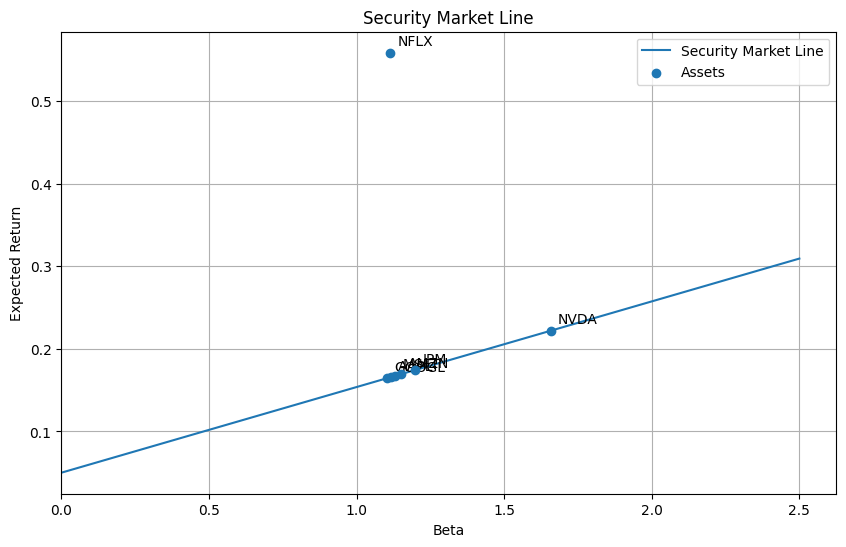

In [15]:
# Descargar y calcular rendimientos de NFLX
nflx_prices = get_prices(["NFLX"], start_date=START, end_date=END)
nflx_returns = compute_returns(nflx_prices, method="simple")["NFLX"]

# Alinear NFLX y SPY por índice
nflx_aligned, spy_aligned = nflx_returns.align(spy_returns, join="inner")

# Estimar beta de NFLX
nflx_beta = estimate_beta(
    nflx_aligned - rf_daily,
    spy_aligned - rf_daily
)

# Rendimiento observado anualizado
nflx_ann_return = annualize_returns(nflx_returns.to_frame(), periods_per_year=252)["NFLX"]

# Rendimiento de equilibrio CAPM
nflx_capm_return = capm_expected_return(risk_free_rate, nflx_beta, market_return)

print(f"Beta NFLX:                    {nflx_beta:.4f}")
print(f"Rendimiento observado NFLX:   {nflx_ann_return:.2%}")
print(f"Rendimiento CAPM NFLX:        {nflx_capm_return:.2%}")
print(f"Alfa de Jensen NFLX:          {nflx_ann_return - nflx_capm_return:.2%}")

# Agregar NFLX al gráfico
all_betas = pd.concat([betas_series, pd.Series({"NFLX": nflx_beta})])
all_returns = pd.concat([pd.Series(capm_returns), pd.Series({"NFLX": nflx_ann_return})])

plot_security_market_line(
    betas=np.linspace(0, 2.5, 100),
    rf=risk_free_rate,
    market_return=market_return,
    asset_betas=all_betas,
    asset_returns=all_returns
)

**Nota:** Los activos del portafolio se ubican sobre la SML por construcción, ya que sus rendimientos esperados se derivaron de las mismas betas y rendimiento de mercado utilizados para construir la línea. NFLX es un activo externo cuyo rendimiento observado no estuvo restringido a la SML, lo que revela su mispricing.

## 7. Modelo de Gordon

Calculamos el valor intrínseco de una acción usando el Modelo de Gordon y el rendimiento requerido implícito a partir del precio de mercado.

In [16]:
from finportfolio.equilibrium import gordon_model, gordon_model_implied_return

# Valor intrínseco de una acción
D1 = 2.50   # dividendo esperado en el próximo periodo
g  = 0.04   # tasa de crecimiento constante de dividendos
r  = 0.09   # tasa de rendimiento requerida

price = gordon_model(D1=D1, g=g, r=r)
print(f"Valor intrínseco: ${price:.2f}")

# Rendimiento implícito a partir del precio de mercado
market_price = 45
implied_r = gordon_model_implied_return(P=market_price, D1=D1, g=g)
print(f"Rendimiento requerido implícito a P=${market_price}: {implied_r:.2%}")

Valor intrínseco: $50.00
Rendimiento requerido implícito a P=$45: 9.56%


El valor intrínseco ($50.00) es el precio al que el rendimiento implícito iguala al rendimiento requerido (9%). Dado que el precio de mercado ($45.00) es menor al valor intrínseco, el rendimiento implícito (9.56%) supera al rendimiento requerido, por lo que el activo está subvaluado.

## 8. Modelo de Índice Simple

Estimamos el Modelo de Índice Simple para Apple ("AAPL"), descomponiendo su riesgo en componentes sistemático e idiosincrático.

In [17]:
from finportfolio.factors import single_index_model

# Estimar el MIS para AAPL
sim_results = single_index_model(returns["AAPL"], spy_returns)
print("Modelo de Índice Simple — AAPL vs SPY:")
print(f"  Alfa (intercepto):      {sim_results['alpha']:.6f}")
print(f"  Beta:                   {sim_results['beta']:.4f}")
print(f"  R-cuadrada:             {sim_results['r_squared']:.4f}")
print(f"  Varianza residual:      {sim_results['residual_variance']:.8f}")
print(f"  Varianza sistemática:   {sim_results['systematic_variance']:.8f}")

Modelo de Índice Simple — AAPL vs SPY:
  Alfa (intercepto):      0.000492
  Beta:                   1.1180
  R-cuadrada:             0.4681
  Varianza residual:      0.00016394
  Varianza sistemática:   0.00014424


## 9. Modelo de Fama-French de 3 Factores

Estimamos el Modelo de Fama-French de 3 Factores para Apple ("AAPL"), agregando los factores de tamaño (SMB) y valor (HML) a la exposición de mercado.

In [18]:
from finportfolio.factors import fama_french_3factor

ff_results = fama_french_3factor(returns["AAPL"], ff_factors)
print("Modelo Fama-French 3 Factores — AAPL:")
print(f"  Alfa:           {ff_results['alpha']:.6f}")
print(f"  Beta Mercado:   {ff_results['beta_market']:.4f}")
print(f"  Beta SMB:       {ff_results['beta_smb']:.4f}")
print(f"  Beta HML:       {ff_results['beta_hml']:.4f}")
print(f"  R-cuadrada:     {ff_results['r_squared']:.4f}")

Modelo Fama-French 3 Factores — AAPL:
  Alfa:           0.000454
  Beta Mercado:   1.1123
  Beta SMB:       -0.2595
  Beta HML:       -0.4438
  R-cuadrada:     0.5085


## 10. Métricas de Desempeño del Portafolio

Evaluamos el portafolio de pesos iguales contra el benchmark SPY utilizando métricas clásicas de desempeño ajustado por riesgo.

In [19]:
from finportfolio.performance import RiskReport

# Portafolio de pesos iguales vs benchmark SPY
equal_weights = pd.Series([1/6] * 6, index=TICKERS)
portfolio_returns = returns @ equal_weights  # Rendimientos diarios del portafolio

report = RiskReport(
    returns_portfolio=portfolio_returns,
    returns_benchmark=spy_returns,
    rf=rf_daily
)

print("Reporte de Desempeño del Portafolio (frecuencia diaria):")
report.summary()

Reporte de Desempeño del Portafolio (frecuencia diaria):


Sharpe Ratio         0.061046
Treynor Ratio        0.000739
Jensen's Alpha       0.000453
Beta                 1.226357
Max Drawdown        -0.377411
VaR (95%)            0.023494
CVaR (95%)           0.034869
Tracking Error       0.007265
Information Ratio    0.073918
M^2 Measure          0.000854
dtype: float64

In [20]:
# VaR y CVaR
var_95 = report.var(confidence_level=0.95, method="historical")
cvar_95 = report.cvar(confidence_level=0.95)
max_dd = report.max_drawdown()

print(f"VaR  (95%, histórico):    {var_95:.2%}")
print(f"CVaR (95%, histórico):    {cvar_95:.2%}")
print(f"Máxima Caída (Drawdown):  {max_dd:.2%}")

VaR  (95%, histórico):    2.35%
CVaR (95%, histórico):    3.49%
Máxima Caída (Drawdown):  -37.74%
